# Visualization Gallery — every chart function, actually rendered

`visualization/` has three chart functions — `plot_equity_curves`, `plot_monte_carlo_fan_chart`,
`plot_vol_surface` — and until this notebook, none of them were ever called outside their own
test file. Tests check the data going *into* the chart (trace values, axis labels); they don't
prove anyone can actually look at the result. This notebook exists to close that gap: build a
minimal, real input for each function and render it for real.

No new findings here — this is a demo, not a research write-up (compare
`docs/research/01_strategy_comparison.md` / `02_profiling.md`, which are).

## 1. `plot_equity_curves`

Three strategies (momentum, mean-reversion, a random baseline) trading the same seeded GBM
path, each through its own `Portfolio` under one `PortfolioManager`, exactly the wiring
`tests/integration/test_portfolio_to_trade.py` and `notebooks/02_strategy_comparison.ipynb`
already establish — the only difference here is calling the real
`visualization.plot_equity_curves` instead of re-deriving the same matplotlib calls inline.

trades executed: 567, rejected orders: 0


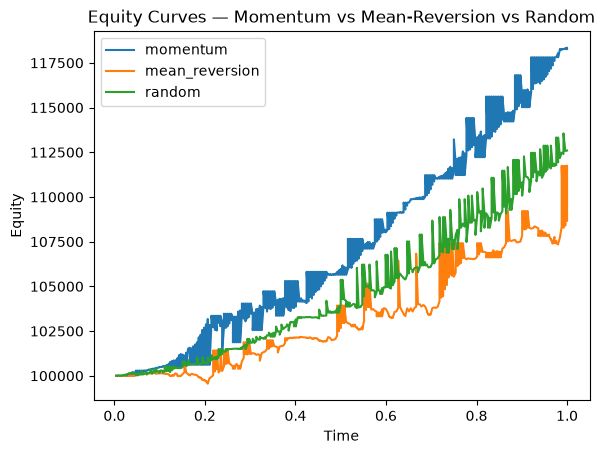

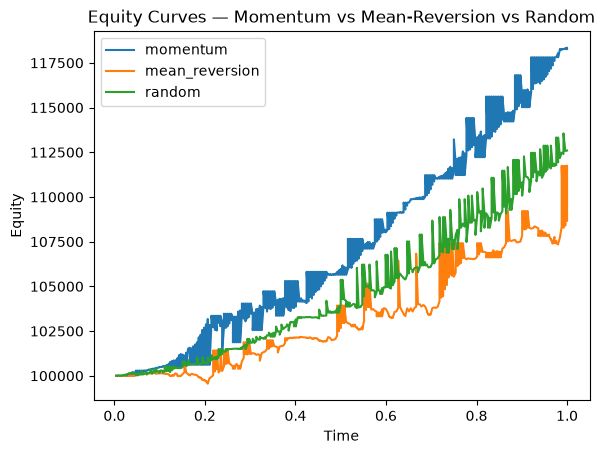

In [1]:
from market_sim.core.config import SimConfig
from market_sim.core.engine.runtime_engine import RuntimeEngine
from market_sim.core.models import EventType
from market_sim.exchange import build_exchange
from market_sim.market.generators import PriceGenerator
from market_sim.market.liquidity import SyntheticLiquidityProvider
from market_sim.portfolio import PortfolioManager
from market_sim.strategies import MeanReversionStrategy, MomentumStrategy, RandomBaseline
from market_sim.visualization import plot_equity_curves

SIM_CONFIG = SimConfig(
    instrument="SIM", initial_price=100.0, mu=0.05, sigma=0.20,
    n_steps=252, dt=1 / 252, seed=42, initial_capital=100_000.0,
)

runtime = RuntimeEngine()
book, trade_log, gateway = build_exchange(runtime)
manager = PortfolioManager()

strategies = {
    "momentum": MomentumStrategy(
        strategy_id="momentum", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, lookback=5, trade_size=10.0,
    ),
    "mean_reversion": MeanReversionStrategy(
        strategy_id="mean_reversion", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, lookback=10, threshold=1.0, trade_size=10.0,
    ),
    "random": RandomBaseline(
        strategy_id="random", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, trade_size=10.0, seed=7,
    ),
}
for strategy_id in strategies:
    manager.register_strategy(strategy_id, initial_cash=100_000.0)

liquidity_provider = SyntheticLiquidityProvider(book)
runtime.loop.register_handler(EventType.MARKET_UPDATE, liquidity_provider.on_market_update)


def on_market_update(event):
    manager.on_market_update(event)
    for strategy_id, strategy in strategies.items():
        for order_event in strategy.on_market_update(event):
            runtime.queue.push(order_event)
            manager.portfolio(strategy_id).track_order(order_event.data["order_id"])


runtime.loop.register_handler(EventType.MARKET_UPDATE, on_market_update)
for strategy in strategies.values():
    runtime.loop.register_handler(EventType.TRADE_EXECUTION, strategy.on_fill)
runtime.loop.register_handler(EventType.TRADE_EXECUTION, manager.on_fill)

price_generator = PriceGenerator(SIM_CONFIG, runtime.clock)
for event in price_generator.generate():
    runtime.queue.push(event)

runtime.start()
print(f"trades executed: {trade_log.trade_count()}, rejected orders: {len(gateway.rejected_orders)}")

fig = plot_equity_curves(
    manager.equity_curves(), title="Equity Curves — Momentum vs Mean-Reversion vs Random"
)
fig

## 2. `plot_monte_carlo_fan_chart`

100 independent full-exchange simulations of `MomentumStrategy` via `MonteCarloRunner`
(seeds 1–100, same GBM config as above but re-seeded per run), then the median-plus-band
chart across every run's equity curve.

mean=27504.92  median=23767.99  std=11608.50  prob_of_loss=0.00%


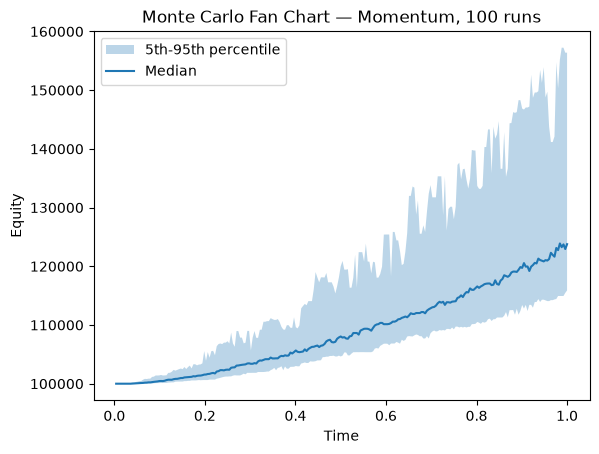

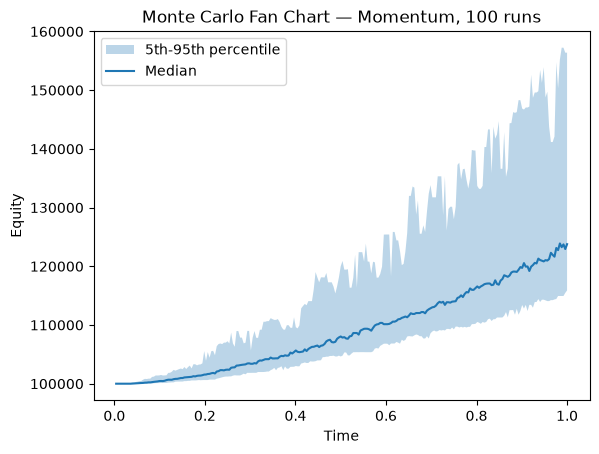

In [2]:
import dataclasses

from market_sim.analytics.monte_carlo import MonteCarloRunner
from market_sim.visualization import plot_monte_carlo_fan_chart


def gbm_factory(seed, clock):
    return PriceGenerator(dataclasses.replace(SIM_CONFIG, seed=seed), clock)


def momentum_factory(clock, order_id_factory):
    return MomentumStrategy(
        strategy_id="mc", initial_cash=100_000.0, clock=clock,
        order_id_factory=order_id_factory, lookback=5, trade_size=10.0,
    )


runner = MonteCarloRunner(
    price_generator_factory=gbm_factory, strategy_factory=momentum_factory,
    n_runs=100, base_seed=1, initial_cash=100_000.0,
)
result = runner.run()
print(
    f"mean={result.mean:.2f}  median={result.median:.2f}  "
    f"std={result.std:.2f}  prob_of_loss={result.prob_of_loss:.2%}"
)

fig = plot_monte_carlo_fan_chart(result, title="Monte Carlo Fan Chart — Momentum, 100 runs")
fig

## 3. `plot_vol_surface`

This simulator has no real options market data (see
`docs/decisions/ADR-008-derivatives-isolation-boundary.md`), so — same technique
`tests/derivatives/test_vol_surface.py` uses as its correctness oracle — a synthetic smile is
priced via `black_scholes_price`, inverted back through `build_vol_surface`, and rendered as
the interactive 3D surface plotly produces.

The smile has to vary with maturity, not just strike, or the "surface" degenerates into a flat
ridge extruded identically across every maturity row — not a mistake `build_vol_surface` can
catch (it round-trips whatever grid it's given exactly), just an unconvincing choice of demo
input. The smile below follows the standard stylized shape instead: curvature that decays with
√T (short-dated skew is more pronounced than long-dated), and an ATM level that rises slightly
with maturity.

In [3]:
import numpy as np

from market_sim.derivatives import OptionType, black_scholes_price, build_vol_surface
from market_sim.visualization import plot_vol_surface

S, r = 100.0, 0.03
strikes = np.array([80.0, 90.0, 100.0, 110.0, 120.0])
maturities = np.array([0.25, 0.5, 1.0, 2.0])


def smile(K: float, T: float) -> float:
    atm = 0.16 + 0.02 * np.sqrt(T)       # ATM vol rises slightly with maturity
    curvature = 0.6 / np.sqrt(T)         # skew flattens as maturity grows
    moneyness = (K - S) / S
    return atm + curvature * moneyness ** 2


market_prices = np.array(
    [
        [black_scholes_price(S, K, T, r, smile(K, T), OptionType.CALL) for K in strikes]
        for T in maturities
    ]
)

surface = build_vol_surface(market_prices, strikes, maturities, S, r, OptionType.CALL)

fig = plot_vol_surface(surface, title="Implied Volatility Surface (synthetic smile, CALL)")
fig